In [1]:
import numpy as np
from numpy.typing import ArrayLike
import pandas as pd
from scipy.stats import multivariate_normal, multinomial, poisson
import pickle

from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid')

np.random.seed(0)

In [2]:
# Import data
df_pop = pd.read_csv('../data/germany-population-2011.csv')

In [3]:
def generate_contact_rate_pattern(A: int = 30, delta: float = 1, C: float = 1/100) -> np.ndarray:
  """Generate a contact pattern matrix using a mixture of 3 bivariate Gaussians"""
  X = np.arange(0, A, delta)
  Y = np.arange(0, A, delta)
  grid = np.array([[i, j] for i in X for j in Y])
  p_main = multivariate_normal.pdf(grid, mean=[15, 15], cov=[[90, 90*0.90], [90*0.90, 90]])
  p_sub1 = multivariate_normal.pdf(grid, mean=[20, 5], cov=[[90, 90*0.80], [90*0.80, 90]])
  p_sub2 = multivariate_normal.pdf(grid, mean=[5, 20], cov=[[90, 90*0.80], [90*0.80, 90]])

  p = (p_main + p_sub1 + p_sub2) / 3
  p = p / p.sum() # Re-normalise

  rate = C * p

  return rate

In [4]:
A = 30
C = 1/200

df_pop_subset = df_pop[(df_pop['gender'] == 'Male') & (df_pop['age'] < 30)]
n = multinomial.rvs(n=2500, p=df_pop_subset['pop'].values / df_pop_subset['pop'].sum())
pop = df_pop_subset['pop'].values

cnt_rate = generate_contact_rate_pattern(A, 1, C)                                 # Generate contact rate pattern
cnt_int = (cnt_rate.reshape(A, A, order='F') * pop[np.newaxis,:]).ravel()  # Contact intensity

print('Minimum contact intensity:', cnt_int.min())
print('Average contact intensity:', cnt_int.mean())
print('Maximum contact intensity:', cnt_int.max())

Minimum contact intensity: 0.16174196610382416
Average contact intensity: 2.309828806371246
Maximum contact intensity: 4.563951552858176


In [5]:
def plot_contact_patterns_matrix(
    cnt_rate: ArrayLike,
    cnt_int: ArrayLike,
    figsize: tuple=(12,6),
    dpi: int=100
  ) -> plt.Figure:
  fig, ax = plt.subplots(1, 2, figsize=figsize, dpi=dpi)

  rate = ax[0].imshow(cnt_rate.reshape(A, A, order='F'), cmap=cm.coolwarm)
  ax[0].invert_yaxis()
  ax[0].set_title('Contact rate pattern')
  ax[0].set_xlabel('Age of contacting individual')
  ax[0].set_ylabel('Age of contact')
  fig.colorbar(rate, ax=ax[0], fraction=0.046, pad=0.04)

  cint = ax[1].imshow(cnt_int.reshape(A, A, order='F'), cmap=cm.Spectral.reversed())
  ax[1].invert_yaxis()
  ax[1].set_title('Contact intensity pattern')
  ax[1].set_xlabel('Age of contacting individual')
  fig.colorbar(cint, ax=ax[1], fraction=0.046, pad=0.04)

  fig.set_tight_layout(True)

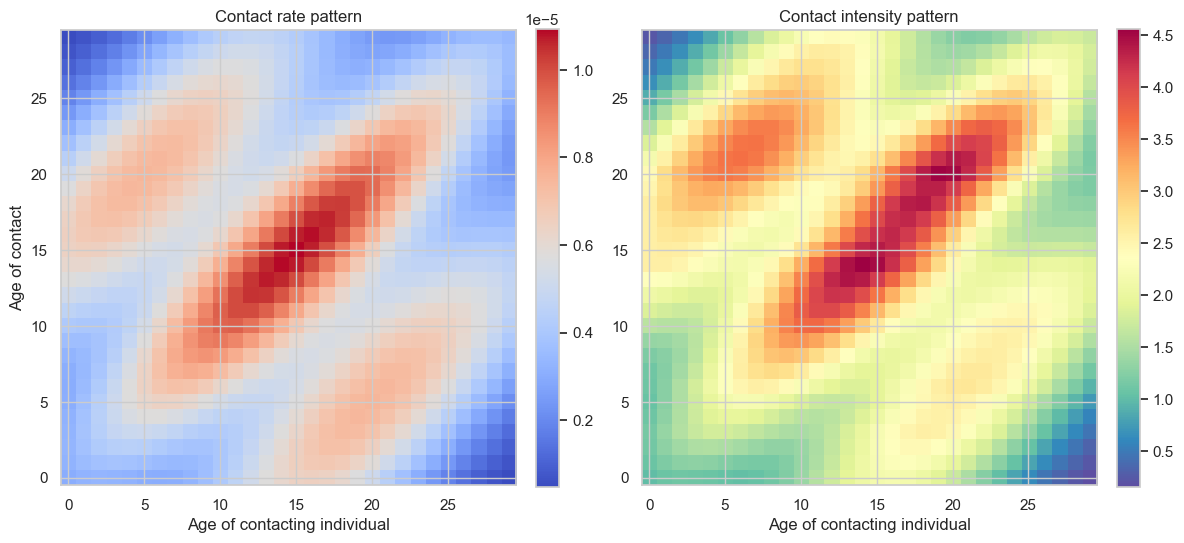

In [6]:
plot_contact_patterns_matrix(cnt_rate, cnt_int)

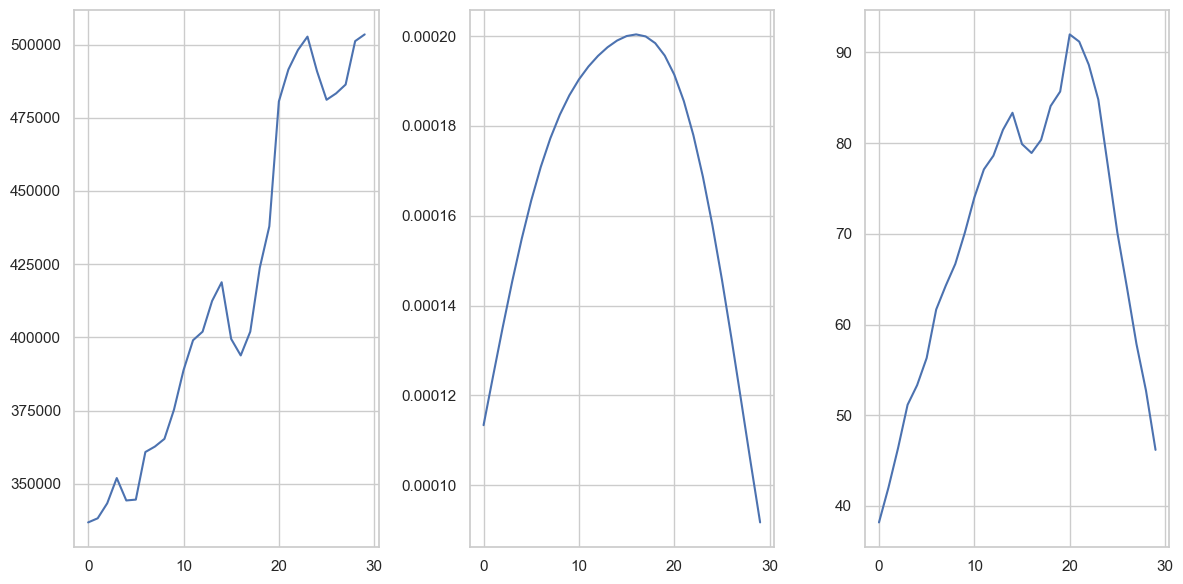

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6), dpi=100)

ax[0].plot(pop)
ax[1].plot(cnt_rate.reshape(A, A, order='F').sum(axis=1))
ax[2].plot(cnt_int.reshape(A, A, order='F').sum(axis=1))

fig.set_tight_layout(True)
plt.show()

In [8]:
# Generate random data
pois_rate = (cnt_int.reshape(A, A, order='F') * n[:,np.newaxis]).ravel(order='F')
y = poisson.rvs(mu=pois_rate)

print('Minimum number of contacts:', y.min())
print('Average number of contacts:', np.median(y))
print('Maximum number of contacts:', y.max())

Minimum number of contacts: 11
Average number of contacts: 182.0
Maximum number of contacts: 482


In [9]:
# Basic data
age_coords = np.array([[a, b] for a in range(A) for b in range(A)])
df = pd.DataFrame({
  'y': y,
  'age_part': age_coords[:,0],
  'age_cnt': age_coords[:,1],
  'n': n[age_coords[:,0]],
  'p': pop[age_coords[:,1]],
  'true_rate': cnt_rate,
  'true_cint': cnt_int
})

df.to_csv('../data/sim/basic.csv', index=False)

In [10]:
def delta2(a, intercept=1/2, slope=1/29):
  return intercept + slope * a

def delta1(a, intercept=3/2, slope=1/29):
  return intercept - (1/2 + slope * a)/2

# Sanity check
assert delta2(29) < 3
assert delta2(0) > 0
assert delta1(29) < 3/2
assert delta1(0) > 0

In [11]:
aid = age_coords[:,0]

cnt_rate0 = delta1(aid) * cnt_rate
cnt_rate1 = delta2(aid) * cnt_rate
cnt_int0 = (cnt_rate0.reshape(A, A) * pop[np.newaxis,:]).ravel()
cnt_int1 = (cnt_rate1.reshape(A, A) * pop[np.newaxis,:]).ravel()
pois_rate0 = (cnt_int0.reshape(A, A) * n[:,np.newaxis]).ravel()
pois_rate1 = (cnt_int1.reshape(A, A) * n[:,np.newaxis]).ravel()

y0 = poisson.rvs(mu=pois_rate0)
y1 = poisson.rvs(mu=pois_rate1)

n0 = n[aid]
n1 = n0
pop0 = np.round(2/3 * pop[aid])
pop1 = np.round(1/3 * pop[aid])

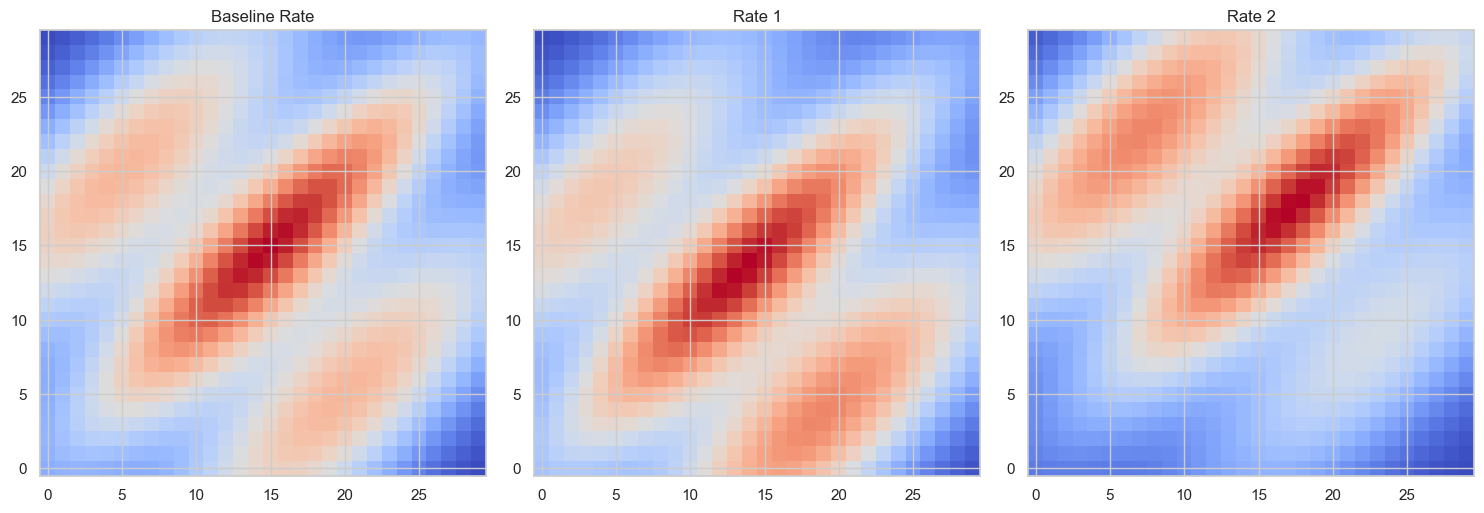

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=100)

ax[0].imshow(cnt_rate.reshape(A, A), cmap='coolwarm', origin='lower')
ax[1].imshow(cnt_rate0.reshape(A, A), cmap='coolwarm', origin='lower')
ax[2].imshow(cnt_rate1.reshape(A, A), cmap='coolwarm', origin='lower')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')

ax[0].set_title('Baseline Rate')
ax[1].set_title('Rate 1')
ax[2].set_title('Rate 2')

fig.set_tight_layout(True)
plt.show()

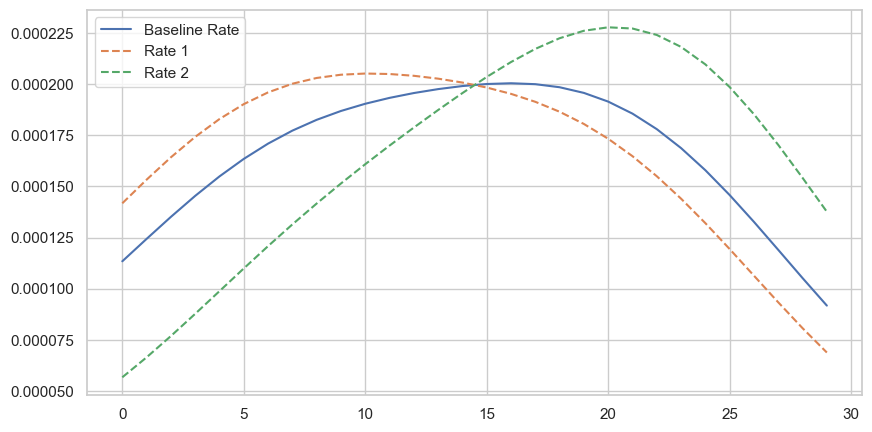

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cnt_rate.reshape(A, A).sum(axis=1), label='Baseline Rate')
ax.plot(cnt_rate0.reshape(A, A).sum(axis=1), label='Rate 1', linestyle='--')
ax.plot(cnt_rate1.reshape(A, A).sum(axis=1), label='Rate 2', linestyle='--')
ax.legend()

plt.show()

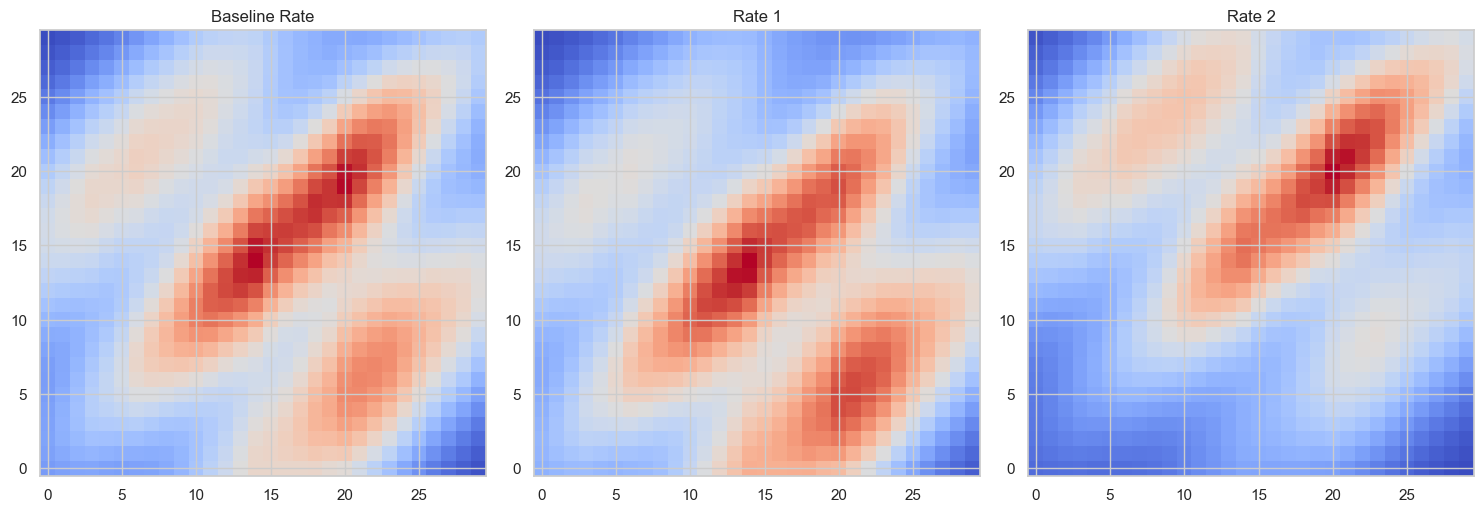

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=100)

ax[0].imshow(cnt_int.reshape(A, A), cmap='coolwarm', origin='lower')
ax[1].imshow(cnt_int0.reshape(A, A), cmap='coolwarm', origin='lower')
ax[2].imshow(cnt_int1.reshape(A, A), cmap='coolwarm', origin='lower')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')

ax[0].set_title('Baseline Rate')
ax[1].set_title('Rate 1')
ax[2].set_title('Rate 2')

fig.set_tight_layout(True)
plt.show()

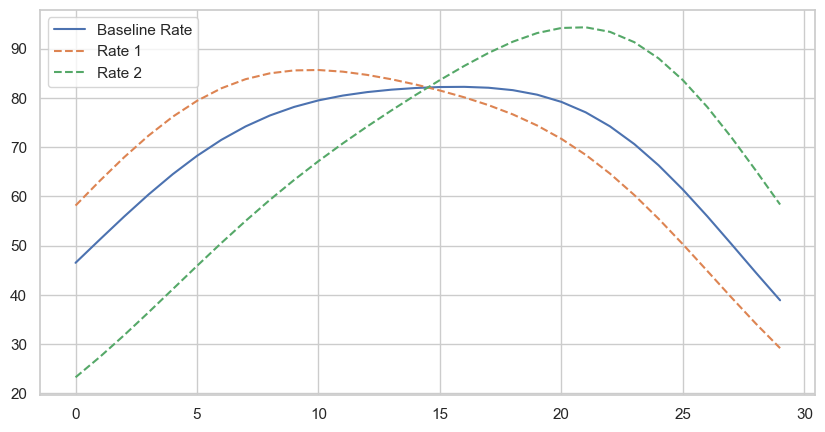

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cnt_int.reshape(A, A).sum(axis=1), label='Baseline Rate')
ax.plot(cnt_int0.reshape(A, A).sum(axis=1), label='Rate 1', linestyle='--')
ax.plot(cnt_int1.reshape(A, A).sum(axis=1), label='Rate 2', linestyle='--')
ax.legend()

plt.show()

In [14]:
df = pd.DataFrame({
  'y': np.concatenate([y0, y1]),
  'age_part': np.concatenate([age_coords[:,0], age_coords[:,0]]),
  'age_cnt': np.concatenate([age_coords[:,1], age_coords[:,1]]),
  'X_a': np.concatenate([np.zeros(A**2), np.ones(A**2)]),
  'n': np.concatenate([n0, n1]),
  'p': np.concatenate([pop[age_coords[:,0]], pop[age_coords[:,0]]])
})

pop_ratio = np.hstack([np.round(2/3*pop)[:,np.newaxis], 
                       np.round(1/3*pop)[:,np.newaxis]])
pop_ratio = {'X_a': pop_ratio / pop[:,np.newaxis]}

data = {'data': df, 'pop_ratio': pop_ratio}

# Pickle data
with open('../data/sim/test_brc_stratified.pkl', 'wb') as f:
  pickle.dump(data, f)